In [ ]:
# STEP 1: IMPORT ALL LIBRARIES

import numpy as np              # Math & arrays
import pandas as pd             # Data tables & manipulation
import matplotlib.pyplot as plt # Plotting graphs
import seaborn as sns           # Better-looking plots
import warnings
warnings.filterwarnings('ignore')

# PREPROCESSING Clean & Prepare Data
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Scale & encode data
from sklearn.model_selection import train_test_split          # Split into train/test

# REGRESSION -Predict Numbers
from sklearn.linear_model import LinearRegression, Ridge, Lasso  # Different regression models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("imported successfully!")


imported successfully!


In [2]:
# STEP 2: LOAD & EXPLORE DATASET

# Load the Pima Indians Diabetes Dataset from GitHub
# This dataset contains 768 patients with 8 medical measurements
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Column names (what each number means)
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(url, names=columns)

# Show basic info
print("Dataset Shape: {} rows × {} columns".format(df.shape[0], df.shape[1]))
print("\n First 5 rows:")
print(df.head())


Dataset Shape: 768 rows × 9 columns

 First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigree  Age  Outcome  
0             0.627   50        1  
1             0.351   31        0  
2             0.672   32        1  
3             0.167   21        0  
4             2.288   33        1  


In [20]:
# STEP 3: Basic Data Summary
# What do our measurements look like? (mean, min, max, etc.)

print("Data Types:")
print(df.dtypes)
df.describe()
print("\ninfo:")
df.info()


Data Types:
Pregnancies           int64
Glucose             float64
BloodPressure       float64
SkinThickness       float64
Insulin             float64
BMI                 float64
DiabetesPedigree    float64
Age                   int64
Outcome               int64
dtype: object

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pregnancies       768 non-null    int64  
 1   Glucose           768 non-null    float64
 2   BloodPressure     768 non-null    float64
 3   SkinThickness     768 non-null    float64
 4   Insulin           768 non-null    float64
 5   BMI               768 non-null    float64
 6   DiabetesPedigree  768 non-null    float64
 7   Age               768 non-null    int64  
 8   Outcome           768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [21]:
# STEP 4: Check for Missing Values
# Missing data = 0 values in medical columns (they should never be exactly 0)

print("Missing Values Count:")
missing = df.isnull().sum()
print(missing)

# Check for 0 values in medical columns (these are actually missing)
medical_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\n Zero counts :")
for col in medical_cols:
    zero_count = (df[col] == 0).sum()
    print(f"  {col}: {zero_count} zeros")


Missing Values Count:
Pregnancies         0
Glucose             0
BloodPressure       0
SkinThickness       0
Insulin             0
BMI                 0
DiabetesPedigree    0
Age                 0
Outcome             0
dtype: int64

 Zero counts :
  Glucose: 0 zeros
  BloodPressure: 0 zeros
  SkinThickness: 0 zeros
  Insulin: 0 zeros
  BMI: 0 zeros


In [ ]:
# STEP 5: Fix Missing Values
# Replace the 0 values with the average (mean) of that column
# This is called "mean imputation"

medical_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in medical_cols:
    # Calculate the average.
    avg = df[df[col] != 0][col].mean()
    # Replace 0s with the average
    df[col] = df[col].replace(0, avg)

print("Missing values fixed!")
print(df.describe())


Missing values fixed!
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.686763      72.405184      29.153420  155.548223   
std       3.369578   30.435949      12.096346       8.790942   85.021108   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.202592      29.153420  155.548223   
75%       6.000000  140.250000      80.000000      32.000000  155.548223   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigree         Age     Outcome  
count  768.000000        768.000000  768.000000  768.000000  
mean    32.457464          0.471876   33.240885    0.348958  
std      6.875151          0.331329   11.760232    0.476951  
min     18.200000          0.078000   21.0000

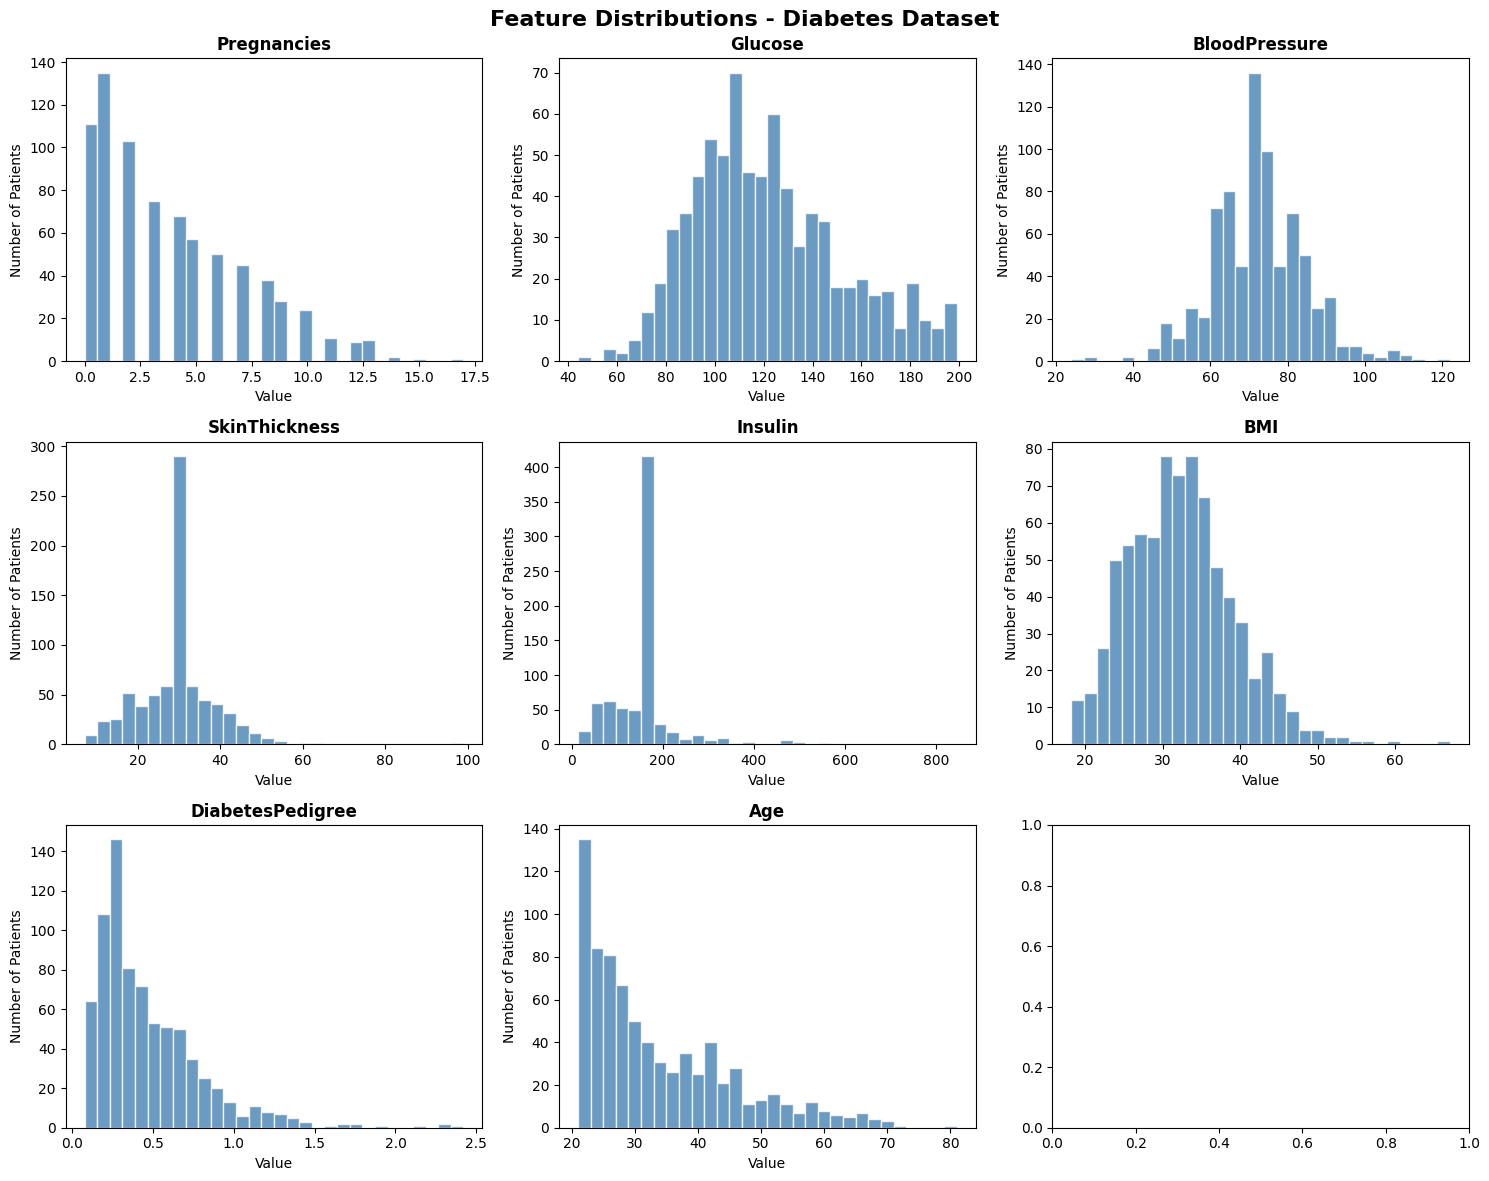

In [18]:
# STEP 6: Visualize Feature Distributions
# See how each measurement is spread out (is it normal? skewed? etc.)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Feature Distributions - Diabetes Dataset', fontsize=16, fontweight='bold')

# Plot histogram for each feature
for idx, col in enumerate(df.columns[:-1]):  # Exclude the Outcome column
    ax = axes[idx // 3][idx % 3]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()


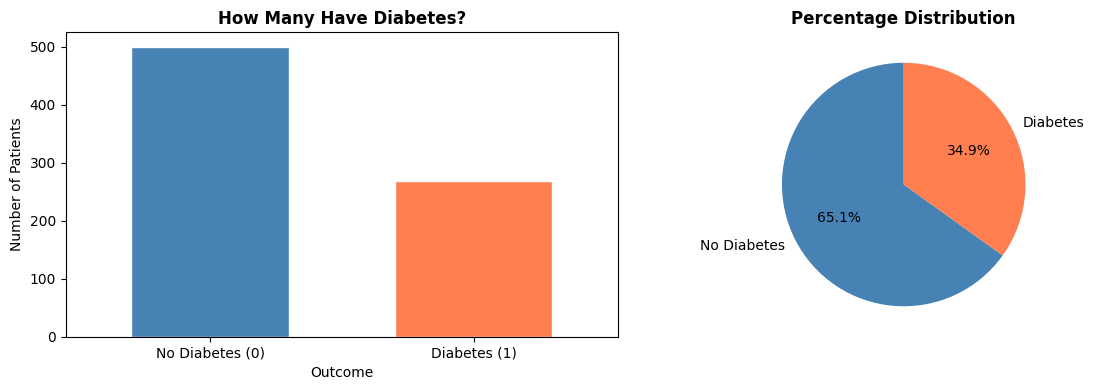

IMPORTANT: Only 34.9% have diabetes!
Dataset is IMBALANCED — We can't just use Accuracy as our metric
Better metrics: Recall & F1 Score


In [ ]:
# STEP 6: Check Class Distribution
# How many patients have diabetes vs don't have diabetes?

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count the two classes
class_counts = df['Outcome'].value_counts()

# Bar chart
class_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white', width=0.6)
axes[0].set_title('How Many Have Diabetes?', fontweight='bold', fontsize=12)
axes[0].set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'], rotation=0)
axes[0].set_ylabel('Number of Patients')

# Pie chart (percentage)
class_counts.plot(kind='pie', ax=axes[1],
                  labels=['No Diabetes', 'Diabetes'],
                  colors=['steelblue', 'coral'],
                  autopct='%1.1f%%',
                  startangle=90)
axes[1].set_title('Percentage Distribution', fontweight='bold', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Important insight
diabetes_pct = (class_counts[1] / class_counts.sum()) * 100
print(f"IMPORTANT: Only {diabetes_pct:.1f}% have diabetes!")
print("Dataset is IMBALANCED — We can't just use Accuracy as our metric")


In [ ]:
# STEP 7: Normalize Features Using StandardScaler
# Why? Age (0-100) and Glucose (0-200) have different ranges
# Machine learning works better when all features are on the same scale (0 to 1)

X = df.drop('Outcome', axis=1)  # Features (input)
y = df['Outcome']               # Target (what we want to predict)

# StandardScaler makes each feature have mean=0 and std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features have been scaled!")
print("\nAfter scaling:")
print(f"  Mean: {X_scaled.mean().round(3).values}")
print(f"  Std Dev: {X_scaled.std().round(3).values}")


Features have been scaled!

After scaling:
  Mean (should be ~0): [-0. -0.  0.  0. -0.  0.  0.  0.]
  Std Dev (should be ~1): [1.001 1.001 1.001 1.001 1.001 1.001 1.001 1.001]


In [ ]:
# STEP 8: Split Data into Train and Test Sets

# Use 80% for training, 20% for testing
# stratify=y means keep the same ratio of diabetes/non-diabetes in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,      # 20% for testing
    stratify=y,          # Keep same ratio in train & test
    random_state=42      # For reproducibility
)

print("Data split complete!")
print(f"\n{'Set':<12} {'Samples':<10} {'Non-Diabetic':<15} {'Diabetic'}")
print("-" * 50)
print(f"{'Training':<12} {len(y_train):<10} {(y_train==0).sum():<15} {y_train.sum()}")
print(f"{'Test':<12} {len(y_test):<10} {(y_test==0).sum():<15} {y_test.sum()}")

print(f"\nModel will learn from {len(y_train)} patients")
print(f"Model will be tested on {len(y_test)} NEW patients")


Data split complete!

Set          Samples    Non-Diabetic    Diabetic
--------------------------------------------------
Training     614        400             214
Test         154        100             54

Model will learn from 614 patients
Model will be tested on 154 NEW patients


In [ ]:
# STEP 9: Prepare Data for Regression
# Predict Glucose level from other features

X_reg = df.drop(['Outcome', 'Glucose'], axis=1)  # All features EXCEPT glucose
y_reg = df['Glucose']                             # Target is glucose level

# Scale the features
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

# Split into train and test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled, y_reg,
    test_size=0.2,
    random_state=42
)

print("Regression Setup:")
print(f"  Predicting: Glucose Level")
print(f"  Training samples: {len(X_train_reg)}")
print(f"  Test samples: {len(X_test_reg)}")
print(f"  Using features: {list(X_reg.columns)}")


Regression Setup:
  Predicting: Glucose Level
  Training samples: 614
  Test samples: 154
  Using features: ['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age']


In [ ]:
# STEP 10: Train Regression Models

reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge (helps prevent overfitting)': Ridge(alpha=1.0),
}

print(f"{'Model':<30} {'MAE':>8} {'RMSE':>8} {'R² Score':>10}")
print("-" * 60)

for name, model in reg_models.items():
    # Train
    model.fit(X_train_reg, y_train_reg)
    
    # Predict on test set
    y_pred = model.predict(X_test_reg)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2 = r2_score(y_test_reg, y_pred)
    
    print(f"{name:<30} {mae:>8.2f} {rmse:>8.2f} {r2:>10.4f}")

print("\nMetrics Explanation:")
print("  MAE: Average error in glucose prediction (lower = better)")
print("  RMSE: Penalizes large errors more (lower = better)")
print("  R² Score: How well the model explains variance (closer to 1 = better)")


Model                               MAE     RMSE   R² Score
------------------------------------------------------------
Linear Regression                 22.49    27.66     0.2396
Ridge (helps prevent overfitting)    22.49    27.66     0.2398

Metrics Explanation:
  MAE: Average error in glucose prediction (lower = better)
  RMSE: Penalizes large errors more (lower = better)
  R² Score: How well the model explains variance (closer to 1 = better)


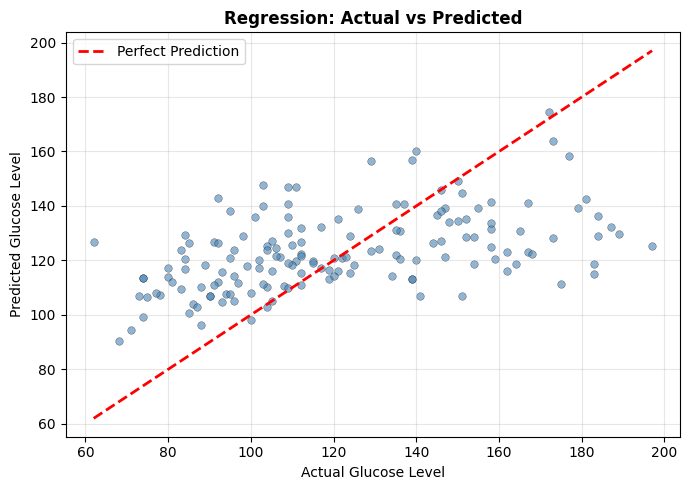

Points close to the red line = good predictions
Points far from the red line = wrong predictions


In [ ]:
# STEP 11: Visualize Regression Results
# Compare actual glucose levels vs what the model predicted

lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)
y_pred_reg = lr.predict(X_test_reg)

plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6, color='steelblue', 
            edgecolors='k', linewidth=0.3, s=30)
plt.plot([y_test_reg.min(), y_test_reg.max()], 
         [y_test_reg.min(), y_test_reg.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Glucose Level')
plt.ylabel('Predicted Glucose Level')
plt.title('Regression: Actual vs Predicted', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Points close to the red line = good predictions")
print("Points far from the red line = wrong predictions")
